## LLM Usage
I have used LLMs in order to ask questions, have a better understanding, getting access to relevant documentation in order to solve the assignment and to get improvement ideas for the code.
### Personal details
Full Name: Jarl Dang <br>
Civic Number: 20010827-9191




## Dependencies

In order to run the application you will need to install certain libraries.

> pip install numpy, matplotlib, tensorflow, keras, scikit-image, scikit-learn

In [1]:
%pip install numpy matplotlib tensorflow keras scikit-image scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Imports
Import the necessary libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from keras import models, layers

## Task 1. Load and format the data
For the MNIST data we min-max scale it and for the CIFAR-10 data we use Z-score normalization

In [4]:
(mnist_image_train, mnist_label_train), (mnist_image_test, mnist_label_test) = (
    tf.keras.datasets.mnist.load_data(path="mnist.npz")
)

mnist_image_train, mnist_image_test = (
    mnist_image_train.astype("float32") / 255.0,
    mnist_image_test.astype("float32") / 255.0,
)

(cifar_image_train, cifar_label_train), (cifar_image_test, cifar_label_test) = (
    tf.keras.datasets.cifar10.load_data()
)

cifar_image_train = cifar_image_train.astype("float32")
cifar_image_test = cifar_image_test.astype("float32")

mean_training = np.mean(cifar_image_train)
std_dev_training = np.std(cifar_image_train)

cifar_image_train = (cifar_image_train - mean_training) / std_dev_training
cifar_image_test = (cifar_image_test - mean_training) / std_dev_training


## Task 2. Building the CNN for MNIST
Now we set up and train the CNN according to the task description for the mnist data using the adam optimizer.

In [ ]:
# CNN for mnist
model = models.Sequential()
# Layer 1 Conv2d, 32 filters, 3x3
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(layers.BatchNormalization())
# Layer 2 max pool 2x2
model.add(layers.MaxPooling2D(2, 2))
# Layer 3 conv2d 64, 3x3
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.BatchNormalization())
# Layer 4 (Maxpool)
model.add(layers.MaxPooling2D(2, 2))
# Layer 5 (flatten, dense, dropout)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.35))
# Layer 6 (dense)
model.add(layers.Dense(10, activation="softmax"))

model.summary()


model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)
# This is the training part using model.fit
history = model.fit(
    mnist_image_train,
    mnist_label_train,
    epochs=10,
    validation_data=(mnist_image_test, mnist_label_test),
)

c:\Users\jarld\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9523 - loss: 0.1606 - val_accuracy: 0.9830 - val_loss: 0.0539
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9796 - loss: 0.0728 - val_accuracy: 0.9881 - val_loss: 0.0440
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9834 - loss: 0.0583 - val_accuracy: 0.9874 - val_loss: 0.0398
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9873 - loss: 0.0443 - val_accuracy: 0.9884 - val_loss: 0.0431
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9885 - loss: 0.0397 - val_accuracy: 0.9908 - val_loss: 0.0379
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9900 - loss: 0.0359 - val_accuracy: 0.9883 - val_loss: 0.0497
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9906 - loss: 0.0309 - val_accuracy: 0.9921 - val_loss: 0.0319
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9924 - loss: 0

## Testing the model
After training the model for 10 epochs we run it on the test data. With this we receive a test accuracy of 0.9927 for the MNIST dataset.

In [ ]:
test_loss, test_accuracy = model.evaluate(mnist_image_test, mnist_label_test)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9927 - loss: 0.0326
Test loss: 0.0326, Test accuracy: 0.9927


## Task 3. Setting up and training the CNN for CIFAR-10
Now we do the same but with a different structure. Since the CIFAR-10 dataset is more difficult to classify I have chosen an approach of increasing the number of layers and also increasing the amount of neurons. Another thing to note is that the border pixels are important this time, thus I have added padding in all of the layers. The size of this padding was chosen to be 'same' which indicates that we add zeroes around the border of the input so that the convolution does not shrink the original image size. This helps preserve edge information and prevets the map size from reducing.

In [ ]:

model_cifar = models.Sequential()
# Layer 1
model_cifar.add(
    layers.Conv2D(
        64, (3, 3), activation="relu", input_shape=(32, 32, 3), padding="same"
    )
)
model_cifar.add(layers.BatchNormalization())

# Layer 2
model_cifar.add(layers.MaxPooling2D(2, 2))

model_cifar.add(
    layers.Conv2D(
        128, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)
    )
)
model_cifar.add(layers.BatchNormalization())
# Layer 3
model_cifar.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
model_cifar.add(layers.BatchNormalization())

# Layer 4
model_cifar.add(layers.MaxPooling2D(2, 2))

# Layer 5
model_cifar.add(layers.Conv2D(512, (3, 3), activation="relu", padding="same"))
model_cifar.add(layers.BatchNormalization())

# Layer 7
model_cifar.add(layers.Conv2D(1024, (3, 3), activation="relu", padding="same"))
model_cifar.add(layers.BatchNormalization())

# Layer 8
model_cifar.add(layers.MaxPooling2D(2, 2))

model_cifar.add(layers.GlobalAveragePooling2D())
model_cifar.add(layers.Dense(256, activation="relu"))
model_cifar.add(layers.Dropout(0.5))
model_cifar.add(layers.Dense(128, activation="relu"))
model_cifar.add(layers.Dropout(0.35))
model_cifar.add(layers.Dense(10, activation="softmax"))


model_cifar.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

history = model_cifar.fit(
    cifar_image_train,
    cifar_label_train,
    epochs=10,
    validation_data=(cifar_image_test, cifar_label_test),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 450s 286ms/step - accuracy: 0.3856 - loss: 1.7101 - val_accuracy: 0.4928 - val_loss: 1.3511
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 283ms/step - accuracy: 0.5719 - loss: 1.2301 - val_accuracy: 0.6682 - val_loss: 0.9639
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 398s 254ms/step - accuracy: 0.6730 - loss: 0.9734 - val_accuracy: 0.7114 - val_loss: 0.8484
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 458s 293ms/step - accuracy: 0.7416 - loss: 0.7826 - val_accuracy: 0.7650 - val_loss: 0.7045
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 466s 298ms/step - accuracy: 0.7973 - loss: 0.6287 - val_accuracy: 0.7765 - val_loss: 0.6527
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 482s 308ms/step - accuracy: 0.8361 - loss: 0.5058 - val_accuracy: 0.8045 - val_loss: 0.6218
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 463s 296ms/step - accuracy: 0.8661 - loss: 0.4232 - val_accuracy: 0.8202 - val_loss: 0.5549
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 435s 279ms/step - ac

## Accuracy Results for CIFAR
Running the test for this model yielded an `accuracy of 0.8239`

In [ ]:
test_loss, test_accuracy = model_cifar.evaluate(cifar_image_test, cifar_label_test)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.8239 - loss: 0.6176
Test loss: 0.6176, Test accuracy: 0.8239


## Other structures
The structure that gave the best result is the one above, but different structures were also tested. One such strucutre had less filters in each convolutional layer where it went from 64 -> 128 -> 256 -> 512 into a dense layer with 128 neurons before the final dense layer with 10 neurons for classification. Otherwise they had identical structures, such as max pooling, batchnorm and dropout. This yielded a slightly lower accuracy of 0.793

<br>

Another structure that was tested was using GlobalAveragePooling instead of flatten in an attempt to reduce the output and overfitting. This is commonly used in modern CNNs according to research. In combination with this change I also tried to reduce the amount of maxpooling layers in an attempt to maintain more spatial information and details. Another change was adding another dense layer in an attempt to improve the end result. This attempt resulted in slightly lower accuracy (0.7970). This suggests that more maxpooling layers in this case gave better results and allowed for the model to focus on the most important features and reduce overfitting by reducing the number of parameters before the dense layers. 

## Task 4. KNN Model
Now we implement a kNN model for classifying both the MNIST and CIFAR-10 dataset. This is implemented according to the instructions with standard Euclidean distance and ran for several k-values to see which one is best. First we implement the necessary functions in order to create our kNN model.

In [7]:


def compute_distances(train_data, test_data):
    """Compute pairwise Euclidean distances between test and train data."""
    train_sq = np.sum(train_data**2, axis=1)  # (N,)
    test_sq = np.sum(test_data**2, axis=1)  # (M,)
    cross = test_data @ train_data.T  # (M, N)
    dists = np.sqrt(
        np.maximum(test_sq[:, None] + train_sq[None, :] - 2 * cross, 0)
    )  # (M, N)
    return dists


def knn_predict_batch(train_data, train_labels, test_data, k):
    """Vectorized KNN prediction for a batch of test points."""
    dists = compute_distances(train_data, test_data)

    # Get k nearest neighbors for each test point
    k_nearest_idx = np.argpartition(dists, k, axis=1)[:, :k]  # (M, k)
    k_nearest_labels = train_labels[k_nearest_idx]  # (M, k)

    # Majority vote per test point
    predictions = np.array(
        [Counter(row).most_common(1)[0][0] for row in k_nearest_labels]
    )
    return predictions


def evaluate_knn(train_data, train_labels, eval_data, eval_labels, k):
    """Evaluate KNN accuracy for a given k."""
    preds = knn_predict_batch(train_data, train_labels, eval_data, k)
    accuracy = np.mean(preds == eval_labels)
    return accuracy

## The main simulation loop
We now use the defined functions to run the main simulation loop. First we flatten the images to 1D vectors in order to get the pixel-by-pixel distance. Then we do standard hold out training where we split the training data and use the last 10 000 as validation. Afterwards we simply sweep over the k-values in order to find the optimal k which yields the highest accuracy for the validation data. 

In [ ]:

def run_knn(
    x_train, y_train, x_test, y_test, dataset_name, k_range=range(1, 26)
):
    """Run KNN: split train into train/val, sweep k, report test accuracy."""
    x_train_flat = x_train.reshape(len(x_train), -1)
    x_test_flat = x_test.reshape(len(x_test), -1)
    y_train_flat = y_train.flatten()
    y_test_flat = y_test.flatten()

    val_size = 10000
    x_val = x_train_flat[-val_size:]
    y_val = y_train_flat[-val_size:]
    x_tr = x_train_flat[:-val_size]
    y_tr = y_train_flat[:-val_size]

    print(f"\n{'=' * 50}")
    print(f"KNN on {dataset_name}")
    print(
        f"Training size: {len(x_tr)}, Validation size: {len(x_val)}, Test size: {len(x_test_flat)}"
    )
    print(f"{'=' * 50}")

    # Sweep k on validation set
    best_k = 1
    best_val_acc = 0.0
    for k in k_range:
        val_acc = evaluate_knn(x_tr, y_tr, x_val, y_val, k)
        print(f"  k={k:2d}  ->  Validation Accuracy: {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_k = k

    print(f"\nBest k = {best_k} (Validation Accuracy: {best_val_acc:.4f})")

    test_acc = evaluate_knn(
        x_train_flat, y_train_flat, x_test_flat, y_test_flat, best_k
    )
    print(f"Test Accuracy with k={best_k}: {test_acc:.4f}")

    return best_k, test_acc

## Running the application
Now we can run the knn model for both the MNIST and CIFAR-10 dataset and print the results. We receive the following values:  <br>
>MNIST:    best k=4, test accuracy=0.9716
> <br>CIFAR-10: best k=5, test accuracy=0.3556

In [ ]:
    mnist_best_k, mnist_test_acc = run_knn(
        mnist_image_train, mnist_label_train, mnist_image_test, mnist_label_test, "MNIST"
    )

    cifar_best_k, cifar_test_acc = run_knn(
        cifar_image_train,
        cifar_label_train,
        cifar_image_test,
        cifar_label_test,
        "CIFAR-10",
    )

    print(f"\n{'=' * 50}")
    print("SUMMARY")
    print(f"{'=' * 50}")
    print(
        f"MNIST:    best k={mnist_best_k}, test accuracy={mnist_test_acc:.4f}"
    )
    print(
        f"CIFAR-10: best k={cifar_best_k}, test accuracy={cifar_test_acc:.4f}"
    )


KNN on MNIST
Training size: 50000, Validation size: 10000, Test size: 10000
  k= 1  ->  Validation Accuracy: 0.9712
  k= 2  ->  Validation Accuracy: 0.9712
  k= 3  ->  Validation Accuracy: 0.9729
  k= 4  ->  Validation Accuracy: 0.9742
  k= 5  ->  Validation Accuracy: 0.9734
  k= 6  ->  Validation Accuracy: 0.9742
  k= 7  ->  Validation Accuracy: 0.9726
  k= 8  ->  Validation Accuracy: 0.9731
  k= 9  ->  Validation Accuracy: 0.9721
  k=10  ->  Validation Accuracy: 0.9712
  k=11  ->  Validation Accuracy: 0.9703
  k=12  ->  Validation Accuracy: 0.9701
  k=13  ->  Validation Accuracy: 0.9686
  k=14  ->  Validation Accuracy: 0.9684
  k=15  ->  Validation Accuracy: 0.9673
  k=16  ->  Validation Accuracy: 0.9678
  k=17  ->  Validation Accuracy: 0.9667
  k=18  ->  Validation Accuracy: 0.9673
  k=19  ->  Validation Accuracy: 0.9656
  k=20  ->  Validation Accuracy: 0.9661
  k=21  ->  Validation Accuracy: 0.9650
  k=22  ->  Validation Accuracy: 0.9652
  k=23  ->  Validation Accuracy: 0.9636
  k

## Task 5. Visualisng the k nearest neighbours
In order to visualise the results better we can improve the kNN code so that for each classified image we also get the k nearest neighbours. Meaning we get the images which the network has calculated is the most similar to the one curently being classified.
<br>
This function works by finding the k closest training images for each seleceted test image. It does this by calculating the distances as the run_knn function. It then displays the test image alongside its k nearest neighbors and also highlighting their labels and distances. For the CIFAR-10 dataset we also show the classname to make it more clear. By doing this we can clearly see what images the network assumes is similar to the test image, this also allows us to analyse what went wrong. In many cases where it misclasifies an image, it is easy to see what it got confused by.

In [ ]:

def visualize_knn(
    x_train,
    y_train,
    x_test,
    y_test,
    k,
    dataset_name,
    num_samples=5,
    img_shape=None,
):
    """Show test images alongside their k nearest neighbors for interpretability."""
    x_train_flat = x_train.reshape(len(x_train), -1)
    x_test_flat = x_test.reshape(len(x_test), -1)
    y_train_flat = y_train.flatten()
    y_test_flat = y_test.flatten()

    cifar10_classes = [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ]

    indices = np.random.choice(len(x_test_flat), num_samples, replace=False)
    dists = compute_distances(x_train_flat, x_test_flat[indices])

    for sample_idx, test_idx in enumerate(indices):
        # Get k nearest neighbor indices sorted by distance
        nn_idx = np.argsort(dists[sample_idx])[:k]
        nn_labels = y_train_flat[nn_idx]
        nn_dists = dists[sample_idx][nn_idx]

        pred_label = Counter(nn_labels).most_common(1)[0][0]
        true_label = y_test_flat[test_idx]
        correct = pred_label == true_label

        fig, axes = plt.subplots(1, k + 1, figsize=(2.5 * (k + 1), 3))
        fig.suptitle(
            f"{dataset_name} — True: {cifar10_classes[true_label] if 'CIFAR' in dataset_name else true_label}, "
            f"Predicted: {cifar10_classes[pred_label] if 'CIFAR' in dataset_name else pred_label} "
            f"({'Correct' if correct else 'WRONG'})",
            fontsize=12,
            color="green" if correct else "red",
            fontweight="bold",
        )

        # Show test image
        test_img = x_test[test_idx]
        if img_shape:
            test_img = test_img.reshape(img_shape)
        cmap = "gray" if test_img.ndim == 2 else None
        # For CIFAR, undo normalization for display
        if test_img.ndim == 3:
            test_img = (test_img - test_img.min()) / (
                test_img.max() - test_img.min()
            )
        axes[0].imshow(test_img, cmap=cmap)
        axes[0].set_title("Test Image", fontsize=10)
        axes[0].axis("off")

        # Show k nearest neighbors
        for j, ni in enumerate(nn_idx):
            neighbor_img = x_train[ni]
            if img_shape:
                neighbor_img = neighbor_img.reshape(img_shape)
            if neighbor_img.ndim == 3:
                neighbor_img = (neighbor_img - neighbor_img.min()) / (
                    neighbor_img.max() - neighbor_img.min()
                )
            lbl = y_train_flat[ni]
            lbl_str = (
                cifar10_classes[lbl] if "CIFAR" in dataset_name else str(lbl)
            )
            axes[j + 1].imshow(neighbor_img, cmap=cmap)
            axes[j + 1].set_title(
                f"NN{j + 1}: {lbl_str}\nd={nn_dists[j]:.2f}", fontsize=9
            )
            axes[j + 1].axis("off")

        plt.tight_layout()
        plt.savefig(f"{dataset_name}_knn_sample_{sample_idx + 1}.png", dpi=150)
        plt.show()

Then we simply run this function for each dataset


Generating KNN visualizations...


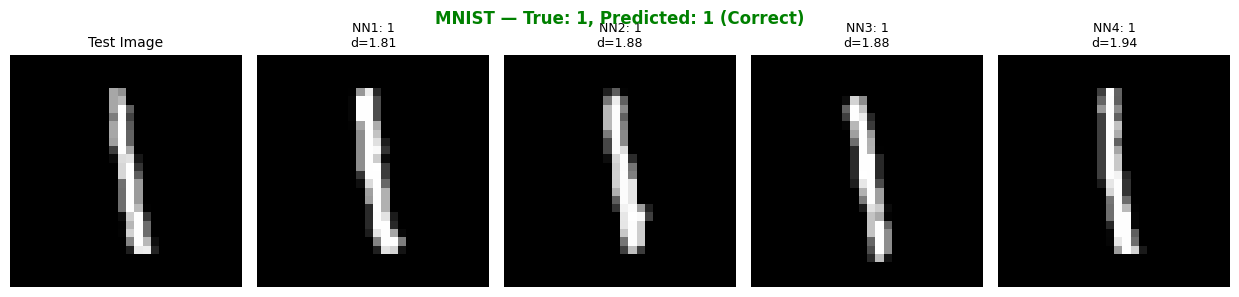

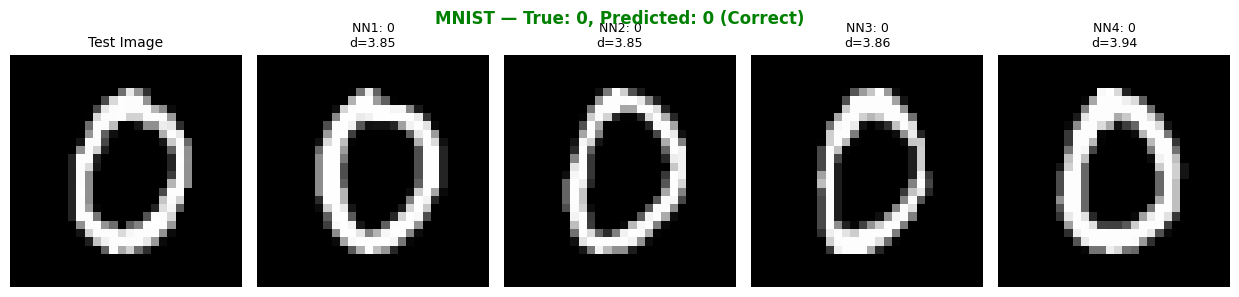

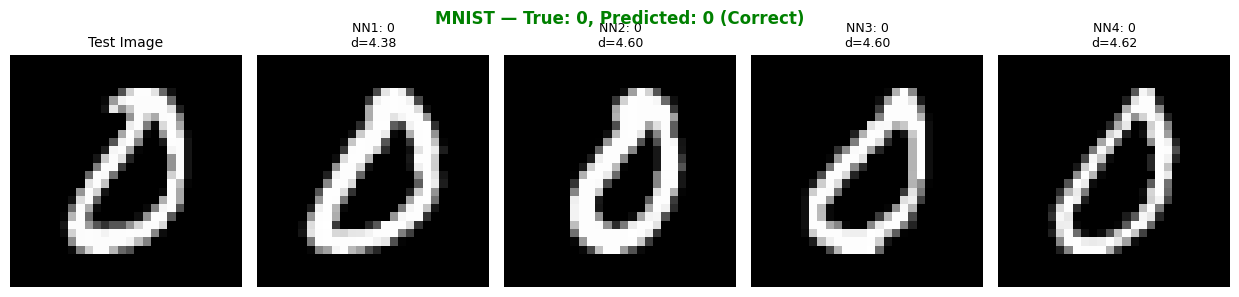

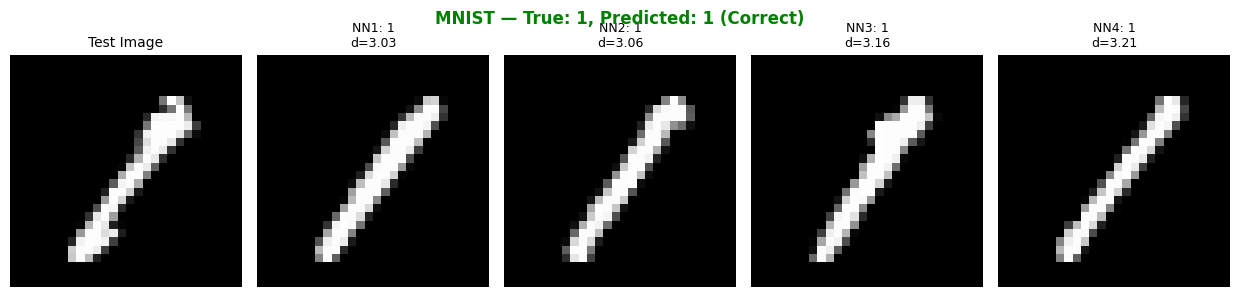

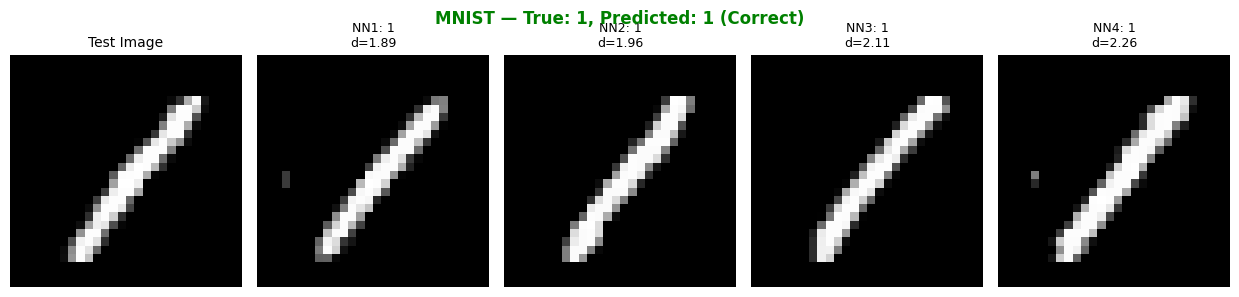

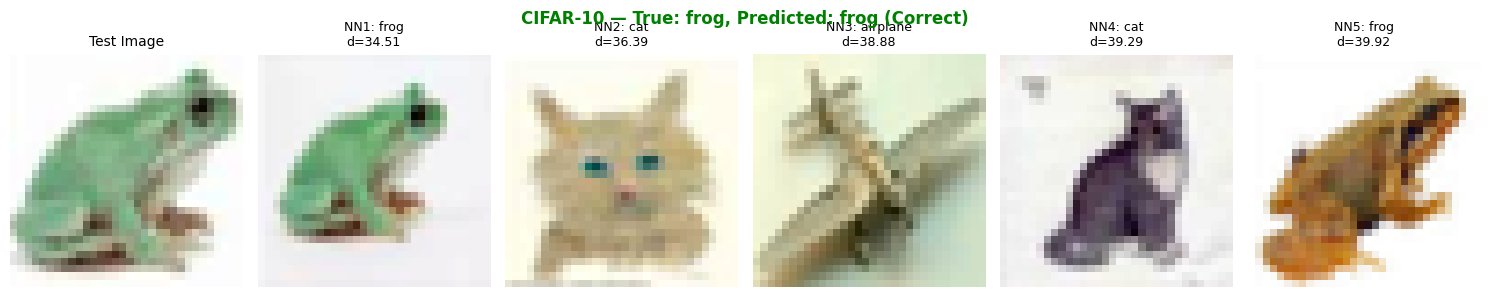

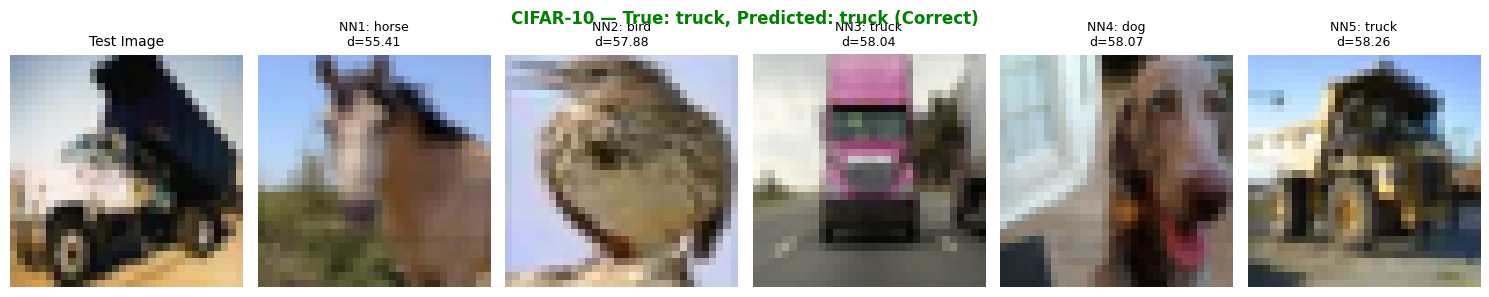

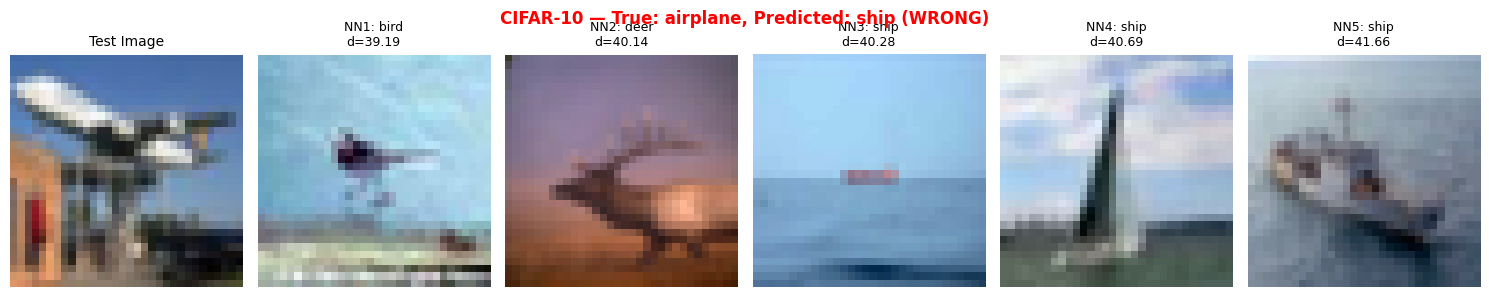

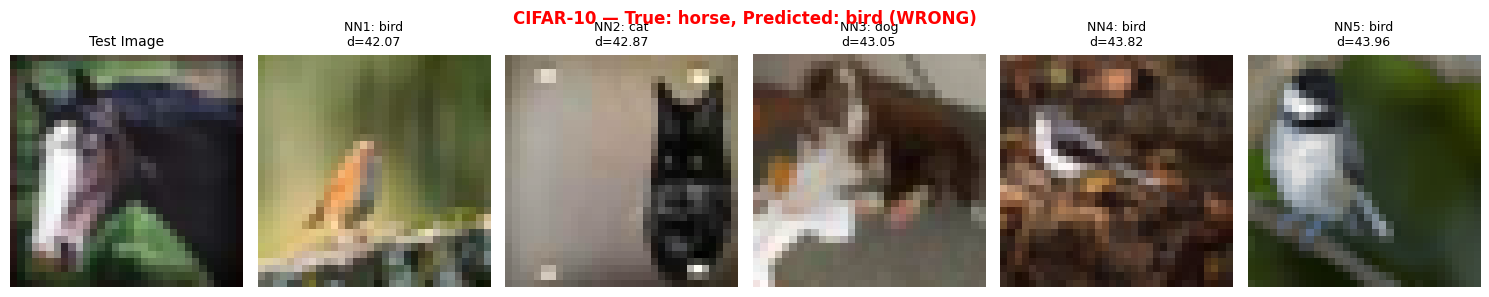

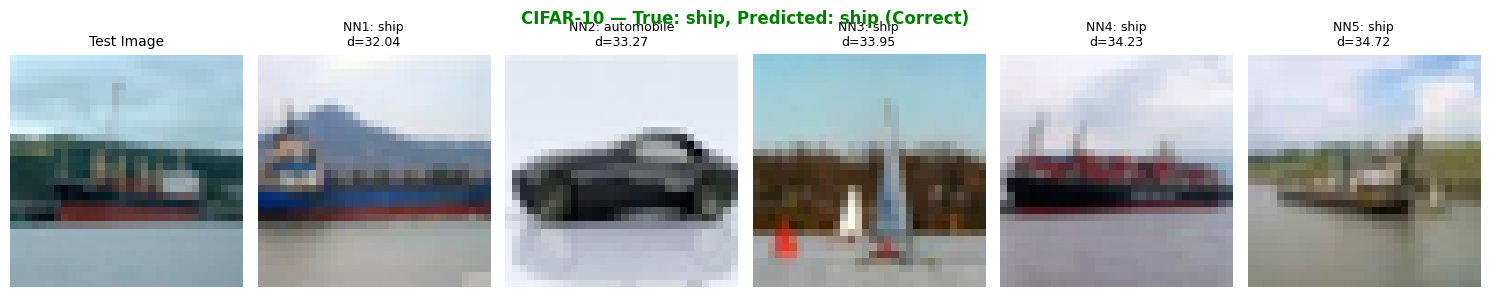

In [ ]:
print("\nGenerating KNN visualizations...") 
visualize_knn(
    mnist_image_train,
    mnist_label_train,
    mnist_image_test,
    mnist_label_test,
    k=mnist_best_k,
    dataset_name="MNIST",
    num_samples=5,
    img_shape=(28, 28),
)
visualize_knn(
    cifar_image_train,
    cifar_label_train,
    cifar_image_test,
    cifar_label_test,
    k=cifar_best_k,
    dataset_name="CIFAR-10",
    num_samples=5,
)

## Task 6. Extending upon the kNN classifier: Bag of Visual Words

The kNN classifier using raw pixel distances performs poorly on CIFAR-10 because individual pixel values are a poor representation of image content. The **Bag of Visual Words (BoVW)** approach improves this by:

1. **Image → HOG patches**: Tile the image into small, partially overlapping patches. For each patch, compute a HOG (Histogram of Oriented Gradients) descriptor vector instead of using raw pixels.
2. **HOG patches → k-Means clustered codebook**: Cluster thousands of HOG vectors into k clusters using K-means. The centroid of each cluster forms a "visual word".
3. **k-Means codebook → Histogram**: For any given image, assign every HOG patch to its nearest visual word and count the occurrences, forming a histogram.
4. **Histogram → kNN classification**: Compute the Euclidean distance between histograms, then use the k-nearest histograms to classify the image.

One note is that using HOG features captures local gradient/edge structure which performs better in gray scale images, thus we make every image grayscale.

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from skimage.feature import hog


def extract_hog_patches(images, orientations=9, pixels_per_cell=4, cells_per_block=2):
    """Extract dense HOG block descriptors from images."""
    all_descriptors = []
    for img in images:
        gray = np.mean(img, axis=2) if img.ndim == 3 else img
        features = hog(
            gray,
            orientations=orientations,
            pixels_per_cell=(pixels_per_cell, pixels_per_cell),
            cells_per_block=(cells_per_block, cells_per_block),
            visualize=False,
            feature_vector=False,
        )
        n_by, n_bx = features.shape[:2]
        descriptors = features.reshape(n_by * n_bx, -1).astype("float32")
        all_descriptors.append(descriptors)
    return all_descriptors


def build_codebook(all_descriptors, n_clusters=128, sample_size=500000):
    """Build a visual word codebook via K-means on a random subset of HOG descriptors."""
    stacked = np.vstack(all_descriptors)
    if len(stacked) > sample_size:
        idx = np.random.choice(len(stacked), sample_size, replace=False)
        stacked = stacked[idx]
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=1024, random_state=10)
    kmeans.fit(stacked)
    return kmeans


def images_to_histograms(all_descriptors, kmeans):
    """Convert per-image HOG descriptors to BoVW histograms."""
    n_clusters = kmeans.n_clusters
    histograms = []
    for descs in all_descriptors:
        labels = kmeans.predict(descs)
        hist = np.bincount(labels, minlength=n_clusters).astype("float32")
        hist_sum = hist.sum()
        if hist_sum > 0:
            hist /= hist_sum
        histograms.append(hist)
    return np.array(histograms)

## Grid Search over HOG parameters
We run a grid search over `pixels_per_cell`, `k`, and `cells_per_block` to find the best combination for each dataset. For efficiency, we use a fixed codebook size and evaluate on the validation set only. Then when we have found the best combination for each dataset we run it with that configuration on the test data to get the final results.

In [ ]:

def grid_search_bovw(x_train, y_train, dataset_name, n_clusters=256):
    """Grid search over pixels_per_cell, cells_per_block and k on validation set."""
    y_train_flat = y_train.flatten()
    val_size = 10000
    y_val = y_train_flat[-val_size:]
    y_tr = y_train_flat[:-val_size]


    # Arbitrarily chosen values, test several
    ppc_values = [2, 4, 6, 8]
    cpb_values = [1, 2, 3,4]
    k_values=[1, 3, 5, 7, 9,11,13,15]
    results = []

    for ppc in ppc_values:
        for cpb in cpb_values:
            img_size = x_train.shape[1]
            if ppc * cpb > img_size:
                print(f"  ppc={ppc}, cpb={cpb} — skipped (block {ppc*cpb}px > image {img_size}px)")
                continue
            try:
                print(f"  ppc={ppc}, cpb={cpb} ...", end=" ", flush=True)
                # These are the main steps for doing the Bag of Visual Words approach.
                descs = extract_hog_patches(x_train, pixels_per_cell=ppc, cells_per_block=cpb)
                kmeans = build_codebook(descs, n_clusters=n_clusters)
                hists = images_to_histograms(descs, kmeans)
                del descs

                x_val_h = hists[-val_size:]
                x_tr_h = hists[:-val_size]

                # Compute distances once, sweep k
                dists = compute_distances(x_tr_h, x_val_h)
                best_k_acc = 0.0
                best_k = k_values[0]
                for k in k_values:
                    k_nearest_idx = np.argpartition(dists, k, axis=1)[:, :k]
                    k_nearest_labels = y_tr[k_nearest_idx]
                    preds = np.array(
                        [Counter(row).most_common(1)[0][0] for row in k_nearest_labels]
                    )
                    val_acc = np.mean(preds == y_val)
                    if val_acc > best_k_acc:
                        best_k_acc = val_acc
                        best_k = k

                hist_dim = x_tr_h.shape[1]
                print(f"best_k={best_k}, val_acc={best_k_acc:.4f}  (hist_dim={hist_dim})")
                results.append((ppc, cpb, best_k, best_k_acc))
                del hists, dists
            except Exception as e:
                print(f"failed: {e}")

    results.sort(key=lambda x: x[3], reverse=True)
    print(f"\n{'=' * 55}")
    print(f"Grid Search Results for {dataset_name} (n_clusters={n_clusters})")
    print(f"{'=' * 55}")
    for ppc, cpb, k, acc in results:
        marker = " <-- BEST" if (ppc, cpb, k, acc) == results[0] else ""
        print(f"  ppc={ppc}, cpb={cpb}, k={k}  ->  val_acc={acc:.4f}{marker}")

    return results[0]  # (best_ppc, best_cpb, best_k, best_acc)


print("Grid search on MNIST...")
best_mnist = grid_search_bovw(mnist_image_train, mnist_label_train, "MNIST", n_clusters=512)
print(f"\nBest MNIST: ppc={best_mnist[0]}, cpb={best_mnist[1]}, k={best_mnist[2]}, val_acc={best_mnist[3]:.4f}")

print("\n\nGrid search on CIFAR-10...")
best_cifar = grid_search_bovw(cifar_image_train, cifar_label_train, "CIFAR-10", n_clusters=512)
print(f"\nBest CIFAR-10: ppc={best_cifar[0]}, cpb={best_cifar[1]}, k={best_cifar[2]}, val_acc={best_cifar[3]:.4f}")

Grid search on MNIST...
  ppc=2, cpb=1 ... best_k=15, val_acc=0.5592  (hist_dim=512)
  ppc=2, cpb=2 ... best_k=11, val_acc=0.7321  (hist_dim=512)
  ppc=2, cpb=3 ... best_k=9, val_acc=0.8838  (hist_dim=512)
  ppc=2, cpb=4 ... best_k=7, val_acc=0.9469  (hist_dim=512)
  ppc=4, cpb=1 ... best_k=15, val_acc=0.5317  (hist_dim=512)
  ppc=4, cpb=2 ... best_k=13, val_acc=0.8837  (hist_dim=512)
  ppc=4, cpb=3 ... best_k=7, val_acc=0.9569  (hist_dim=512)
  ppc=4, cpb=4 ... best_k=3, val_acc=0.9614  (hist_dim=512)
  ppc=6, cpb=1 ... best_k=15, val_acc=0.5489  (hist_dim=512)
  ppc=6, cpb=2 ... best_k=7, val_acc=0.9202  (hist_dim=512)
  ppc=6, cpb=3 ... best_k=7, val_acc=0.9491  (hist_dim=512)
  ppc=6, cpb=4 ... best_k=15, val_acc=0.9586  (hist_dim=512)
  ppc=8, cpb=1 ... best_k=15, val_acc=0.5335  (hist_dim=512)
  ppc=8, cpb=2 ... best_k=7, val_acc=0.8906  (hist_dim=512)
  ppc=8, cpb=3 ... best_k=13, val_acc=0.9257  (hist_dim=512)
  ppc=8, cpb=4 — skipped (block 32px > image 28px)

Grid Search Resu

## BoVW results
After running the best combination we find the following results:

> <br> Best CIFAR-10: ppc=8, cpb=3, k=15, val_acc=0.4128
> <br> Best MNIST: ppc=4, cpb=4, k=3, val_acc=0.9614

These results are slightly worse for the MNIST case and slightly better for the CIFAR case. One reason why it may perform worse in the MNIST case is that the histograms for number are quite similar, since it does not take any spatial features into account. A six would therefore look almost identical to a 9. 